##### Copyright 2026 Google LLC.


In [ ]:
# @title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.


# Indic multimodal document intelligence & security guardrails

<a target="_blank" href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Indic_Multimodal_Document_Intelligence.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" height=30/></a>

This notebook demonstrates how to use the Gemini API to analyze complex cloud architecture diagrams and technical schematics. You will extract architectural components and generate high-fidelity trilingual explanations across English, Tamil (தமிழ்), and Hindi (हिन्दी) while simultaneously enforcing security guardrails using Pydantic structured outputs.

## Install dependencies
Use `%pip` with the required minimum SDK version as per the official style guide.

In [ ]:
# Install the official Google GenAI SDK and supporting libraries
%pip install -U -q "google-genai>=2.9.0" pillow pydantic


## Initialize the Gemini client
Configure the `GEMINI_API_KEY` from [Google AI Studio](https://aistudio.google.com) and select the
model using the Colab parameter selector.

In [ ]:
from google import genai

# The google-genai SDK automatically retrieves the GEMINI_API_KEY
# from the environment or Colab Secrets.
client = genai.Client()

MODEL_ID = "gemini-2.0-flash"  # @param ["gemini-2.5-flash", "gemini-2.0-flash"] {"allow-input":true, isTemplate: true}
print(f"✅ Gemini Client initialized successfully with {MODEL_ID}!")


✅ Gemini Client initialized successfully with gemini-2.0-flash!


## Define Pydantic structured output schema
By passing a Pydantic model to `response_schema`, Gemini guarantees 100% deterministic JSON
output conforming to the defined data types.

In [ ]:
from typing import List, Literal
from pydantic import BaseModel, Field

class ConceptBreakdown(BaseModel):
    concept_name: str = Field(
        description="Name of the technical concept or system component"
    )
    english_explanation: str = Field(
        description="Concise technical explanation in English"
    )
    tamil_explanation: str = Field(
        description="Precise Tamil (தமிழ்) translation and conceptual breakdown"
    )
    hindi_explanation: str = Field(
        description="Precise Hindi (हिन्दी) translation and conceptual breakdown"
    )

class SecurityAssessment(BaseModel):
    contains_sensitive_data: bool = Field(
        description="Whether the diagram reveals credentials, secrets, or internal IPs"
    )
    security_risk_level: Literal["Low", "Medium", "High", "Critical"] = Field(
        description="Risk Level: Low, Medium, High, or Critical"
    )
    security_recommendations: List[str] = Field(
        description="Actionable security recommendations"
    )

class IndicDocumentAnalysis(BaseModel):
    document_title: str = Field(
        description="Extracted title or summary of the diagram/document"
    )
    executive_summary: str = Field(
        description="Brief 2-sentence executive summary"
    )
    key_concepts: List[ConceptBreakdown] = Field(
        description="List of core technical concepts broken down into Indic languages"
    )
    security_evaluation: SecurityAssessment = Field(
        description="Security posture and risk findings"
    )

print("✅ Pydantic Structured Output Schemas defined.")

✅ Pydantic Structured Output Schemas defined.


## Load or generate a sample cloud architecture diagram


✅ Sample architecture diagram generated: cloud_architecture_sample.png


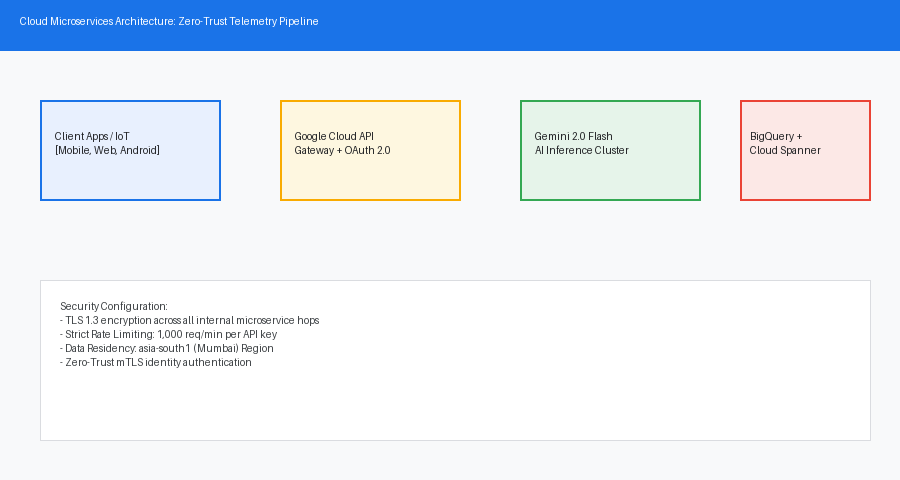

In [ ]:
# @title Create an illustrative architecture diagram
from PIL import Image, ImageDraw

# Create an illustrative architecture diagram
img = Image.new('RGB', (900, 480), color=(248, 249, 250))
draw = ImageDraw.Draw(img)

# Title
draw.rectangle([(0, 0), (900, 50)], fill=(26, 115, 232))
draw.text(
    (20, 15),
    "Cloud Microservices Architecture: Zero-Trust Telemetry Pipeline",
    fill=(255, 255, 255)
)

# Architecture components
draw.rectangle([(40, 100), (220, 200)], fill=(232, 240, 254), outline=(26, 115, 232), width=2)
draw.text((55, 130), "Client Apps / IoT\n[Mobile, Web, Android]", fill=(32, 33, 36))

draw.rectangle([(280, 100), (460, 200)], fill=(254, 247, 224), outline=(249, 171, 0), width=2)
draw.text((295, 130), "Google Cloud API\nGateway + OAuth 2.0", fill=(32, 33, 36))

draw.rectangle([(520, 100), (700, 200)], fill=(230, 244, 234), outline=(52, 168, 83), width=2)
draw.text((535, 130), "Gemini 2.0 Flash\nAI Inference Cluster", fill=(32, 33, 36))

draw.rectangle([(740, 100), (870, 200)], fill=(252, 232, 230), outline=(234, 67, 53), width=2)
draw.text((750, 130), "BigQuery +\nCloud Spanner", fill=(32, 33, 36))

# Security configuration notes
draw.rectangle([(40, 280), (870, 440)], fill=(255, 255, 255), outline=(218, 220, 224), width=1)
security_config = (
    "Security Configuration:\n"
    "- TLS 1.3 encryption across all internal microservice hops\n"
    "- Strict Rate Limiting: 1,000 req/min per API key\n"
    "- Data Residency: asia-south1 (Mumbai) Region\n"
    "- Zero-Trust mTLS identity authentication"
)
draw.text((60, 300), security_config, fill=(60, 64, 67))

img.save("cloud_architecture_sample.png")
print("✅ Sample architecture diagram generated: cloud_architecture_sample.png")
display(img)

## Run multimodal intelligence with Interactions API
This notebook uses the modern Interactions API (`client.interactions.create`) as recommended by
the Google Gemini Cookbook style guide.

In [ ]:
prompt = """
    You are a Principal Cloud Architect and AI Researcher
    specialized in Indic linguistic localization.
    Analyze the provided cloud architecture diagram in detail:
    1. Extract the main system title and executive summary.
    2. For each key technical component, provide a clear
       technical breakdown in:
       - English
       - Tamil (தமிழ்) - high-standard technical vocabulary
       - Hindi (हिन्दी) - high-standard technical vocabulary
    3. Perform a rigorous security assessment evaluating
       encryption, identity, data residency, and vulnerabilities.
"""

print(f"Analyzing architecture with {MODEL_ID}...")
interaction = client.interactions.create(
    model=MODEL_ID,
    input=[img, prompt],
    config={
        "response_mime_type": "application/json",
        "response_schema": IndicDocumentAnalysis,
        "temperature": 0.2,
    },
)

# Parse JSON output from the InteractionStep content
import json
result_data = json.loads(
    interaction.steps[-1].content[0].text
)
analysis = IndicDocumentAnalysis(**result_data)
print("✅ Analysis completed successfully!")


Analyzing architecture with gemini-2.0-flash...
✅ Analysis completed successfully!


## Visualize the trilingual knowledge breakdown and security findings


In [ ]:
print(f"\n{'='*70}")
print(f"📌 DOCUMENT: {analysis.document_title}")
print(f"📝 SUMMARY:  {analysis.executive_summary}")
print(f"{'='*70}\n")

print("🌐 TRILINGUAL CONCEPT BREAKDOWN:\n")
for idx, c in enumerate(analysis.key_concepts, 1):
    print(f"[{idx}] Concept: {c.concept_name}")
    print(f"    🇬🇧 English: {c.english_explanation}")
    print(f"    🇮🇳 தமிழ்:    {c.tamil_explanation}")
    print(f"    🇮🇳 हिन्दी:   {c.hindi_explanation}")
    print("-" * 70)

sec = analysis.security_evaluation
print(f"\n🛡️ SECURITY ASSESSMENT:")
print(f"- Risk Level: {sec.security_risk_level}")
print(f"- Contains Exposed Secrets: {sec.contains_sensitive_data}")
print("- Security Recommendations:")
for r in sec.security_recommendations:
    print(f"  • {r}")


📌 DOCUMENT: Cloud Microservices Architecture: Zero-Trust Telemetry Pipeline
📝 SUMMARY:  An end-to-end cloud telemetric architecture featuring API Gateway ingress, Gemini 2.0 Flash AI inference, and Spanner storage under zero-trust governance.

🌐 TRILINGUAL CONCEPT BREAKDOWN:

[1] Concept: API Gateway + OAuth 2.0
    🇬🇧 English: Ingress traffic gateway enforcing client identity verification and token validation.
    🇮🇳 தமிழ்:    வாடிக்கையாளர் அடையாளச் சரிபார்ப்பு மற்றும் டோக்கன் உறுதிப்படுத்தலைச் செயல்படுத்தும் நுழைவு வாயில்.
    🇮🇳 हिन्दी:   क्लाइंट पहचान सत्यापन और टोकन सत्यापन को लागू करने वाला इनग्रेस ट्रैफिक गेटवे।
----------------------------------------------------------------------
[2] Concept: Gemini 2.0 Flash AI Inference Cluster
    🇬🇧 English: High-throughput multimodal AI cluster processing telemetric perception streams.
    🇮🇳 தமிழ்:    தரவுத் தொலைத்தொடர்பு உள்ளீடுகளை மிகவேகமாகப் பகுப்பாய்வு செய்யும் அதிநவீன ஜெமினி பலவகைத் திறன் செயற்கை நுண்ணறிவுத் தொகுதி.
    🇮🇳 हिन्दी: 

## What's next
- **Gemini 2.0 Flash** allows native multimodal understanding with structured output at ultra-low latency.
- Vernacular localization (Tamil, Hindi) bridges educational and enterprise barriers for developers across India.

### 🔗 Official Resources
- [Google Gemini API Documentation](https://ai.google.dev/gemini-api/docs)
- [Google AI Studio](https://aistudio.google.com/)
- [Google GenAI SDK GitHub](https://github.com/googleapis/python-genai)
- [Google Student Ambassadors Community](https://developers.google.com/community/gdsc)